In [2]:
import pandas as pd

In [3]:
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.shape

(99441, 8)

In [6]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [7]:
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [8]:
orders.info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [9]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [10]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [11]:
orders.groupby("order_status")["order_delivered_customer_date"].apply(
    lambda x: x.isnull().sum()
)

order_status
approved          2
canceled        619
created           5
delivered         8
invoiced        314
processing      301
shipped        1107
unavailable     609
Name: order_delivered_customer_date, dtype: int64

In [12]:
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


In [13]:
delivered_missing_date = (
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
).sum()

total_delivered = (orders["order_status"] == "delivered").sum()

print("Delivered orders:", total_delivered)
print("Missing delivery dates:", delivered_missing_date)
print("Percentage:", round(delivered_missing_date / total_delivered * 100, 2), "%")

Delivered orders: 96478
Missing delivery dates: 8
Percentage: 0.01 %


In [14]:
orders["order_id"].duplicated().sum()

np.int64(0)

In [15]:
orders.duplicated().sum()

np.int64(0)

In [16]:
orders["order_purchase_timestamp"].head()

0    2017-10-02 10:56:33
1    2018-07-24 20:41:37
2    2018-08-08 08:38:49
3    2017-11-18 19:28:06
4    2018-02-13 21:18:39
Name: order_purchase_timestamp, dtype: str

In [17]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [18]:
orders["order_purchase_timestamp"].dtype

dtype('<M8[us]')

In [19]:
date_columns = [
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

In [20]:
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [21]:
orders.dtypes


order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [22]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)

In [23]:
orders[["order_id", "order_purchase_timestamp", "order_delivered_customer_date", "delivery_days"]].head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2.873877


In [24]:
round(orders["delivery_days"].mean(), 2)

np.float64(12.56)

In [25]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64

In [26]:
orders.nlargest(10, "delivery_days")[
    ["order_id", "order_purchase_timestamp",
     "order_delivered_customer_date", "delivery_days"]
]

,order_id,order_purchase_timestamp,order_delivered_customer_date,delivery_days
19590,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:27,2017-09-19 14:36:39,209.628611
55619,1b3190b2dfa9d789e1f14c05b647a14a,2018-02-23 14:57:35,2018-09-19 23:24:07,208.351759
61610,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:51,2017-09-19 15:12:50,195.634016
70307,2fb597c2f772eca01b1f5c561bf6cc7b,2017-03-08 18:09:02,2017-09-19 14:33:17,194.850174
89130,285ab9426d6982034523a855f55a885e,2017-03-08 22:47:40,2017-09-19 14:00:04,194.633611
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:57,2017-09-19 14:38:21,194.049583
11399,47b40429ed8cce3aee9199792275433f,2018-01-03 09:44:01,2018-07-13 20:51:31,191.463542
81401,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:10,2017-09-19 17:00:07,189.863160
54480,2d7561026d542c8dbd8f0daeadf67a43,2017-03-15 11:24:27,2017-09-19 14:38:18,188.134618
68769,c27815f7e3dd0b926b58552628481575,2017-03-15 23:23:17,2017-09-19 17:14:25,187.743843


In [27]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / (60 * 60 * 24)

In [28]:
orders[
    ["order_id",
     "order_estimated_delivery_date",
     "order_delivered_customer_date",
     "delivery_delay_days"]
].head()

,order_id,order_estimated_delivery_date,order_delivered_customer_date,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-18,2017-10-10 21:25:13,-7.107488
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-13,2018-08-07 15:27:45,-5.355729
2,47770eb9100c2d0c44946d9cf07ec65d,2018-09-04,2018-08-17 18:06:29,-17.245498
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-15,2017-12-02 00:28:42,-12.980069
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-26,2018-02-16 18:17:02,-9.238171


In [29]:
orders["delivery_delay_days"].describe()

count    96476.000000
mean       -11.179120
std         10.186113
min       -146.016123
25%        -16.244384
50%        -11.948941
75%         -6.390000
max        188.975081
Name: delivery_delay_days, dtype: float64

In [30]:
late_deliveries = (orders["delivery_delay_days"] > 0).sum()

valid_deliveries = orders["delivery_delay_days"].notna().sum()

late_delivery_rate = late_deliveries / valid_deliveries * 100

print("Late deliveries:", late_deliveries)
print("Valid deliveries:", valid_deliveries)
print("Late delivery rate:", round(late_delivery_rate, 2), "%")

Late deliveries: 7827
Valid deliveries: 96476
Late delivery rate: 8.11 %


In [31]:
orders.nlargest(10, "delivery_delay_days")[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_estimated_delivery_date",
        "order_delivered_customer_date",
        "delivery_delay_days"
    ]
]

,order_id,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,delivery_delay_days
55619,1b3190b2dfa9d789e1f14c05b647a14a,2018-02-23 14:57:35,2018-03-15,2018-09-19 23:24:07,188.975081
19590,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:27,2017-03-22,2017-09-19 14:36:39,181.608785
11399,47b40429ed8cce3aee9199792275433f,2018-01-03 09:44:01,2018-01-19,2018-07-13 20:51:31,175.869109
81401,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:10,2017-04-05,2017-09-19 17:00:07,167.708414
89130,285ab9426d6982034523a855f55a885e,2017-03-08 22:47:40,2017-04-06,2017-09-19 14:00:04,166.583380
61610,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:51,2017-04-07,2017-09-19 15:12:50,165.633912
68769,c27815f7e3dd0b926b58552628481575,2017-03-15 23:23:17,2017-04-10,2017-09-19 17:14:25,162.718345
40847,d24e8541128cea179a11a65176e0a96f,2017-06-12 13:14:11,2017-06-26,2017-12-04 18:36:29,161.775336
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:57,2017-04-11,2017-09-19 14:38:21,161.609965
54480,2d7561026d542c8dbd8f0daeadf67a43,2017-03-15 11:24:27,2017-04-13,2017-09-19 14:38:18,159.609931


In [32]:
orders[
    orders["order_delivered_customer_date"].dt.date == pd.to_datetime("2017-09-19").date()
].shape[0]

282

In [33]:
orders["order_delivered_customer_date"].dt.date.value_counts().head(10)

order_delivered_customer_date
2018-08-27    446
2018-08-13    442
2018-05-14    434
2018-05-21    431
2018-05-18    425
2018-04-11    413
2017-12-11    412
2018-07-03    410
2018-05-03    409
2018-07-30    405
Name: count, dtype: int64

In [34]:
orders["delivery_year"] = orders["order_delivered_customer_date"].dt.year

In [35]:
orders.groupby("delivery_year")["delivery_delay_days"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
delivery_year,,,,
2016.0,272,-35.739233,-38.661377,36.324745
2017.0,40930,-12.109236,-12.350874,181.608785
2018.0,55274,-10.369517,-11.082731,188.975081


In [36]:
orders.groupby("delivery_year")["delivery_delay_days"].apply(
    lambda x: (x > 0).mean() * 100
).round(2)

delivery_year
2016.0     1.47
2017.0     5.25
2018.0    10.27
Name: delivery_delay_days, dtype: float64

In [37]:
orders["purchase_year"] = orders["order_purchase_timestamp"].dt.year

In [38]:
orders.groupby("purchase_year")["delivery_delay_days"].apply(
    lambda x: (x > 0).mean() * 100
).round(2)

purchase_year
2016    1.22
2017    6.38
2018    9.16
Name: delivery_delay_days, dtype: float64

## Delivery Performance Findings

- Average delivery time: 12.56 days.
- Median delivery time: 10.22 days.
- Overall late-delivery rate: 8.11%.
- Late-delivery rate for orders purchased in 2017: 6.38%.
- Late-delivery rate for orders purchased in 2018: 9.16%.
- The late-delivery rate increased by 2.78 percentage points from 2017 to 2018.
- Several extreme delivery delays were identified and should be investigated rather than automatically removed.

In [39]:
import os

os.listdir("../data")

['processed', 'raw']

In [40]:
os.listdir("../data/raw")

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [41]:
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")

In [42]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [43]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [44]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [45]:
order_items.duplicated().sum()

np.int64(0)

In [46]:
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

In [47]:
order_items["shipping_limit_date"].dtype

dtype('<M8[us]')

In [48]:
total_revenue = order_items["price"].sum()
print("Total Product Revenue:", round(total_revenue, 2))

Total Product Revenue: 13591643.7


In [49]:
total_freight = order_items["freight_value"].sum()
print("Total Freight Value:", round(total_freight,2))

Total Freight Value: 2251909.54


In [50]:
total_order_value = order_items["price"].sum() + order_items["freight_value"].sum()
print("Total Order Value:", round(total_order_value,2))

Total Order Value: 15843553.24


In [51]:
total_orders = order_items["order_id"].nunique()
print("Total Unique Orders:", total_orders)

Total Unique Orders: 98666


In [52]:
aov = total_revenue / total_orders

print("Average Order Value:", round(aov, 2))

Average Order Value: 137.75


In [53]:
sales = order_items.merge(
    orders[["order_id", "order_purchase_timestamp"]],
    on="order_id",
    how="left"
)

In [54]:
sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-04 13:57:51


In [55]:
sales["purchase_month"] = sales["order_purchase_timestamp"].dt.to_period("M")

In [56]:
sales[["order_purchase_timestamp", "purchase_month"]].head()

,order_purchase_timestamp,purchase_month
0,2017-09-13 08:59:02,2017-09
1,2017-04-26 10:53:06,2017-04
2,2018-01-14 14:33:31,2018-01
3,2018-08-08 10:00:35,2018-08
4,2017-02-04 13:57:51,2017-02


In [57]:
monthly_revenue = (
    sales.groupby("purchase_month")["price"]
    .sum()
    .reset_index()
)

monthly_revenue.head(10)

,purchase_month,price
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02
5,2017-03,374344.30
6,2017-04,359927.23
7,2017-05,506071.14
8,2017-06,433038.60
9,2017-07,498031.48


In [58]:
monthly_revenue

,purchase_month,price
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02
5,2017-03,374344.30
6,2017-04,359927.23
7,2017-05,506071.14
8,2017-06,433038.60
9,2017-07,498031.48


In [59]:
monthly_revenue["previous_month_revenue"] = monthly_revenue["price"].shift(1)

In [60]:
monthly_revenue["revenue_change"] = (
    monthly_revenue["price"] -
    monthly_revenue["previous_month_revenue"]
)

In [61]:
monthly_revenue["revenue_change_pct"] = (
    monthly_revenue["revenue_change"] /
    monthly_revenue["previous_month_revenue"] * 100
).round(2)

In [62]:
monthly_revenue

,purchase_month,price,previous_month_revenue,revenue_change,revenue_change_pct
0,2016-09,267.36,NaN,NaN,NaN
1,2016-10,49507.66,267.36,49240.30,18417.23
2,2016-12,10.90,49507.66,-49496.76,-99.98
3,2017-01,120312.87,10.90,120301.97,1103687.80
4,2017-02,247303.02,120312.87,126990.15,105.55
5,2017-03,374344.30,247303.02,127041.28,51.37
6,2017-04,359927.23,374344.30,-14417.07,-3.85
7,2017-05,506071.14,359927.23,146143.91,40.60
8,2017-06,433038.60,506071.14,-73032.54,-14.43
9,2017-07,498031.48,433038.60,64992.88,15.01


In [63]:
monthly_revenue.sort_values(
    "price",
    ascending=False
).head(10)

,purchase_month,price,previous_month_revenue,revenue_change,revenue_change_pct
13,2017-11,1010271.37,664219.43,346051.94,52.10
18,2018-04,996647.75,983213.44,13434.31,1.37
19,2018-05,996517.68,996647.75,-130.07,-0.01
17,2018-03,983213.44,844178.71,139034.73,16.47
15,2018-01,950030.36,743914.17,206116.19,27.71
21,2018-07,895507.22,865124.31,30382.91,3.51
20,2018-06,865124.31,996517.68,-131393.37,-13.19
22,2018-08,854686.33,895507.22,-40820.89,-4.56
16,2018-02,844178.71,950030.36,-105851.65,-11.14
14,2017-12,743914.17,1010271.37,-266357.20,-26.36


In [64]:
monthly_orders = (
    sales.groupby("purchase_month")["order_id"]
    .nunique()
    .reset_index(name="unique_orders")
)

monthly_orders.head(10)

,purchase_month,unique_orders
0,2016-09,3
1,2016-10,308
2,2016-12,1
3,2017-01,789
4,2017-02,1733
5,2017-03,2641
6,2017-04,2391
7,2017-05,3660
8,2017-06,3217
9,2017-07,3969


In [65]:
monthly_sales = monthly_revenue.merge(
    monthly_orders,
    on="purchase_month",
    how="left"
)

In [66]:
monthly_sales

,purchase_month,price,previous_month_revenue,revenue_change,revenue_change_pct,unique_orders
0,2016-09,267.36,NaN,NaN,NaN,3
1,2016-10,49507.66,267.36,49240.30,18417.23,308
2,2016-12,10.90,49507.66,-49496.76,-99.98,1
3,2017-01,120312.87,10.90,120301.97,1103687.80,789
4,2017-02,247303.02,120312.87,126990.15,105.55,1733
5,2017-03,374344.30,247303.02,127041.28,51.37,2641
6,2017-04,359927.23,374344.30,-14417.07,-3.85,2391
7,2017-05,506071.14,359927.23,146143.91,40.60,3660
8,2017-06,433038.60,506071.14,-73032.54,-14.43,3217
9,2017-07,498031.48,433038.60,64992.88,15.01,3969


In [67]:
monthly_sales["aov"] = (
    monthly_sales["price"] /
    monthly_sales["unique_orders"]
).round(2)

In [68]:
monthly_sales

,purchase_month,price,previous_month_revenue,revenue_change,revenue_change_pct,unique_orders,aov
0,2016-09,267.36,NaN,NaN,NaN,3,89.12
1,2016-10,49507.66,267.36,49240.30,18417.23,308,160.74
2,2016-12,10.90,49507.66,-49496.76,-99.98,1,10.90
3,2017-01,120312.87,10.90,120301.97,1103687.80,789,152.49
4,2017-02,247303.02,120312.87,126990.15,105.55,1733,142.70
5,2017-03,374344.30,247303.02,127041.28,51.37,2641,141.74
6,2017-04,359927.23,374344.30,-14417.07,-3.85,2391,150.53
7,2017-05,506071.14,359927.23,146143.91,40.60,3660,138.27
8,2017-06,433038.60,506071.14,-73032.54,-14.43,3217,134.61
9,2017-07,498031.48,433038.60,64992.88,15.01,3969,125.48


In [69]:
declining_months = monthly_sales[
    monthly_sales["revenue_change"] < 0
]

declining_months[
    ["purchase_month", "price", "revenue_change_pct", "unique_orders", "aov"]
]

,purchase_month,price,revenue_change_pct,unique_orders,aov
2,2016-12,10.90,-99.98,1,10.90
6,2017-04,359927.23,-3.85,2391,150.53
8,2017-06,433038.60,-14.43,3217,134.61
14,2017-12,743914.17,-26.36,5624,132.27
16,2018-02,844178.71,-11.14,6694,126.11
19,2018-05,996517.68,-0.01,6853,145.41
20,2018-06,865124.31,-13.19,6160,140.44
22,2018-08,854686.33,-4.56,6452,132.47
23,2018-09,145.00,-99.98,1,145.00


In [70]:
monthly_sales[
    monthly_sales["purchase_month"].astype(str).isin(["2017-11", "2017-12"])
][
    ["purchase_month", "price", "unique_orders", "aov"]
]

,purchase_month,price,unique_orders,aov
13,2017-11,1010271.37,7451,135.59
14,2017-12,743914.17,5624,132.27


In [71]:
products = pd.read_csv("../data/raw/olist_products_dataset.csv")

In [72]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [73]:
sales = sales.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

In [74]:
sales[[
    "order_id",
    "product_id",
    "price",
    "product_category_name"
]].head()

,order_id,product_id,price,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,pet_shop
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,ferramentas_jardim


In [75]:
category_revenue = (
    sales.groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

In [76]:
category_revenue.head(10)

,product_category_name,price
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


In [77]:
category_monthly = (
    sales[
        sales["purchase_month"].astype(str).isin(["2017-11", "2017-12"])
    ]
    .groupby(["purchase_month", "product_category_name"])["price"]
    .sum()
    .reset_index()
)

In [78]:
category_monthly.head(10)

,purchase_month,product_category_name,price
0,2017-11,agro_industria_e_comercio,13932.49
1,2017-11,alimentos,556.95
2,2017-11,alimentos_bebidas,2445.57
3,2017-11,artes,75.00
4,2017-11,artigos_de_festas,870.69
5,2017-11,artigos_de_natal,1340.58
6,2017-11,audio,3677.23
7,2017-11,automotivo,34955.38
8,2017-11,bebes,21738.78
9,2017-11,bebidas,748.61


In [79]:
category_compare = category_monthly.pivot(
    index="product_category_name",
    columns="purchase_month",
    values="price"
).fillna(0)

In [80]:
category_compare.head(10)

purchase_month,2017-11,2017-12
product_category_name,,
agro_industria_e_comercio,13932.49,5291.70
alimentos,556.95,978.19
alimentos_bebidas,2445.57,1098.68
artes,75.00,115.25
artigos_de_festas,870.69,515.20
artigos_de_natal,1340.58,493.90
audio,3677.23,2686.93
automotivo,34955.38,39287.64
bebes,21738.78,19943.08


In [81]:
category_compare["revenue_change"] = (
    category_compare["2017-12"] -
    category_compare["2017-11"]
)

In [82]:
category_compare.sort_values(
    "revenue_change"
).head(10)

purchase_month,2017-11,2017-12,revenue_change
product_category_name,,,
cama_mesa_banho,89412.54,50505.85,-38906.69
informatica_acessorios,72656.00,37880.65,-34775.35
moveis_decoracao,63223.97,32011.75,-31212.22
relogios_presentes,97724.57,71727.62,-25996.95
ferramentas_jardim,45972.18,27689.69,-18282.49
beleza_saude,79120.40,61264.66,-17855.74
cool_stuff,56295.24,39011.54,-17283.70
telefonia,26564.88,13611.01,-12953.87
moveis_escritorio,18048.20,6964.36,-11083.84


In [83]:
category_orders = (
    sales[
        sales["purchase_month"].astype(str).isin(["2017-11", "2017-12"])
    ]
    .groupby(["purchase_month", "product_category_name"])["order_id"]
    .nunique()
    .reset_index(name="unique_orders")
)

In [84]:
category_orders.head(10)

,purchase_month,product_category_name,unique_orders
0,2017-11,agro_industria_e_comercio,13
1,2017-11,alimentos,11
2,2017-11,alimentos_bebidas,28
3,2017-11,artes,1
4,2017-11,artigos_de_festas,4
5,2017-11,artigos_de_natal,20
6,2017-11,audio,33
7,2017-11,automotivo,245
8,2017-11,bebes,190
9,2017-11,bebidas,15


In [85]:
category_orders_compare = category_orders.pivot(
    index="product_category_name",
    columns="purchase_month",
    values="unique_orders"
).fillna(0)

In [86]:
category_orders_compare["order_change"] = (
    category_orders_compare["2017-12"] -
    category_orders_compare["2017-11"]
)

In [87]:
category_orders_compare.sort_values(
    "order_change"
).head(10)

purchase_month,2017-11,2017-12,order_change
product_category_name,,,
cama_mesa_banho,817.0,481.0,-336.0
moveis_decoracao,547.0,315.0,-232.0
informatica_acessorios,444.0,252.0,-192.0
ferramentas_jardim,433.0,245.0,-188.0
esporte_lazer,557.0,440.0,-117.0
telefonia,351.0,244.0,-107.0
utilidades_domesticas,353.0,249.0,-104.0
beleza_saude,530.0,432.0,-98.0
relogios_presentes,430.0,346.0,-84.0


## Revenue Analysis Checkpoint

### Key Findings

- Total product revenue: 13.59M
- Total unique orders: 98,666
- Overall AOV: 137.75
- November 2017 was the highest-revenue month at 1.01M.
- December 2017 revenue declined 26.36% from November.
- December's order volume declined approximately 24.52%.
- AOV declined approximately 2.45%.
- The December decline was primarily driven by fewer orders.
- The largest category revenue declines were:
  - cama_mesa_banho: -38,906.69
  - informatica_acessorios: -34,775.35
  - moveis_decoracao: -31,212.22
- Category order declines support the conclusion that lower order volume was a major driver.

In [88]:
product_monthly = (
    sales[
        sales["purchase_month"].astype(str).isin(["2017-11", "2017-12"])
    ]
    .groupby(["purchase_month", "product_id"])["price"]
    .sum()
    .reset_index()
)

In [89]:
product_compare = product_monthly.pivot(
    index="product_id",
    columns="purchase_month",
    values="price"
).fillna(0)

In [90]:
product_compare.columns

PeriodIndex(['2017-11', '2017-12'], dtype='period[M]', name='purchase_month')

In [91]:
product_compare["revenue_change"] = (
    product_compare[pd.Period("2017-12", freq="M")] -
    product_compare[pd.Period("2017-11", freq="M")]
)

In [92]:
product_compare.sort_values(
    "revenue_change"
).head(10)

purchase_month,2017-11,2017-12,revenue_change
product_id,,,
6a162a899a815ed15db1689e8efc976c,6349.00,0.00,-6349.00
c183fd5d2abf05873fa6e1014ed9e06c,5934.60,0.00,-5934.60
588531f8ec37e7d5ff5b7b22ea0488f8,5748.00,0.00,-5748.00
dc404a1496a08f9f5540c8b5d4b92925,6299.79,599.98,-5699.81
223d34a3d9334039f5ff9511dc044bbb,4439.16,0.00,-4439.16
431d674f9a4fbd0957ecf6ba3fcb6899,4328.90,707.70,-3621.20
011ae9863bd5b15e528a16dd8ceb4772,3249.50,0.00,-3249.50
5f504b3a1c75b73d6151be81eb05bdc9,4270.00,1236.00,-3034.00
2b69866f22de8dad69c976771daba91c,2990.00,0.00,-2990.00


In [93]:
top_declining_products = product_compare.sort_values(
    "revenue_change"
).head(10).reset_index()

In [94]:
top_declining_products = top_declining_products.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

In [95]:
top_declining_products

,product_id,2017-11,2017-12,revenue_change,product_category_name
0,6a162a899a815ed15db1689e8efc976c,6349.00,0.00,-6349.00,cool_stuff
1,c183fd5d2abf05873fa6e1014ed9e06c,5934.60,0.00,-5934.60,agro_industria_e_comercio
2,588531f8ec37e7d5ff5b7b22ea0488f8,5748.00,0.00,-5748.00,pcs
3,dc404a1496a08f9f5540c8b5d4b92925,6299.79,599.98,-5699.81,brinquedos
4,223d34a3d9334039f5ff9511dc044bbb,4439.16,0.00,-4439.16,telefonia
5,431d674f9a4fbd0957ecf6ba3fcb6899,4328.90,707.70,-3621.20,telefonia
6,011ae9863bd5b15e528a16dd8ceb4772,3249.50,0.00,-3249.50,brinquedos
7,5f504b3a1c75b73d6151be81eb05bdc9,4270.00,1236.00,-3034.00,cool_stuff
8,2b69866f22de8dad69c976771daba91c,2990.00,0.00,-2990.00,agro_industria_e_comercio
9,389d119b48cf3043d311335e499d9c6b,4712.19,1769.70,-2942.49,ferramentas_jardim


In [96]:
product_orders = (
    sales[
        sales["purchase_month"].astype(str).isin(["2017-11", "2017-12"])
    ]
    .groupby(["purchase_month", "product_id"])["order_id"]
    .nunique()
    .reset_index(name="unique_orders")
)

In [97]:
product_orders_compare = product_orders.pivot(
    index="product_id",
    columns="purchase_month",
    values="unique_orders"
).fillna(0)

In [98]:
product_orders_compare["order_change"] = (
    product_orders_compare[pd.Period("2017-12", freq="M")] -
    product_orders_compare[pd.Period("2017-11", freq="M")]
)

In [99]:
product_orders_compare.sort_values(
    "order_change"
).head(10)

purchase_month,2017-11,2017-12,order_change
product_id,,,
422879e10f46682990de24d770e7f83d,72.0,28.0,-44.0
389d119b48cf3043d311335e499d9c6b,64.0,28.0,-36.0
53759a2ecddad2bb87a079a1f1519f73,67.0,31.0,-36.0
368c6c730842d78016ad823897a372db,56.0,28.0,-28.0
99a4788cb24856965c36a24e339b6058,39.0,17.0,-22.0
461f43be3bdf8844e65b62d9ac2c7a5a,25.0,6.0,-19.0
dc404a1496a08f9f5540c8b5d4b92925,21.0,2.0,-19.0
42a2c92a0979a949ca4ea89ec5c7b934,31.0,14.0,-17.0
223d34a3d9334039f5ff9511dc044bbb,16.0,0.0,-16.0


In [100]:
product_orders_compare = product_orders_compare.reset_index()

product_orders_compare = product_orders_compare.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

In [101]:
product_orders_compare.sort_values(
    "order_change"
).head(10)

,product_id,2017-11,2017-12,order_change,product_category_name
1750,422879e10f46682990de24d770e7f83d,72.0,28.0,-44.0,ferramentas_jardim
1494,389d119b48cf3043d311335e499d9c6b,64.0,28.0,-36.0,ferramentas_jardim
2221,53759a2ecddad2bb87a079a1f1519f73,67.0,31.0,-36.0,ferramentas_jardim
1427,368c6c730842d78016ad823897a372db,56.0,28.0,-28.0,ferramentas_jardim
4070,99a4788cb24856965c36a24e339b6058,39.0,17.0,-22.0,cama_mesa_banho
1861,461f43be3bdf8844e65b62d9ac2c7a5a,25.0,6.0,-19.0,relogios_presentes
5848,dc404a1496a08f9f5540c8b5d4b92925,21.0,2.0,-19.0,brinquedos
1767,42a2c92a0979a949ca4ea89ec5c7b934,31.0,14.0,-17.0,utilidades_domesticas
911,223d34a3d9334039f5ff9511dc044bbb,16.0,0.0,-16.0,telefonia
4226,9ecadb84c81da840dbf3564378b586e9,17.0,2.0,-15.0,moveis_decoracao


In [102]:
category_order_change = (
    product_orders_compare
    .groupby("product_category_name")["order_change"]
    .sum()
    .sort_values()
)

In [103]:
category_order_change.head(10)

product_category_name
cama_mesa_banho          -380.0
moveis_decoracao         -252.0
informatica_acessorios   -204.0
ferramentas_jardim       -199.0
telefonia                -106.0
esporte_lazer            -106.0
beleza_saude             -104.0
utilidades_domesticas    -104.0
relogios_presentes        -89.0
perfumaria                -65.0
Name: order_change, dtype: float64

In [104]:
import os

os.getcwd()

'c:\\Users\\Anuj\\AI-Sales-Analyst\\notebooks'

In [105]:
os.listdir()

['.ipynb_checkpoints', '01_data_exploration.ipynb']

In [106]:
customers = pd.read_csv(
    "../data/raw/olist_customers_dataset.csv"
)

In [107]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [108]:
orders_customers = orders.merge(
    customers[["customer_id", "customer_city", "customer_state"]],
    on="customer_id",
    how="left"
)

In [109]:
orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,delivery_year,purchase_year,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,-7.107488,2017.0,2017,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,-5.355729,2018.0,2018,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,-17.245498,2018.0,2018,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750,-12.980069,2017.0,2017,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877,-9.238171,2018.0,2018,santo andre,SP


In [110]:
sales_location = order_items.merge(
    orders_customers[[
        "order_id",
        "order_purchase_timestamp",
        "customer_city",
        "customer_state"
    ]],
    on="order_id",
    how="left"
)

In [111]:
sales_location["purchase_month"] = (
    sales_location["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [112]:
sales_location.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_purchase_timestamp,customer_city,customer_state,purchase_month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-13 08:59:02,campos dos goytacazes,RJ,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-04-26 10:53:06,santa fe do sul,SP,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-14 14:33:31,para de minas,MG,2018-01
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-08 10:00:35,atibaia,SP,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-04 13:57:51,varzea paulista,SP,2017-02


In [113]:
state_compare = (
    sales_location[
        sales_location["purchase_month"].isin(
            [pd.Period("2017-11"), pd.Period("2017-12")]
        )
    ]
    .groupby(["customer_state", "purchase_month"])["price"]
    .sum()
    .unstack(fill_value=0)
)

In [114]:
state_compare["revenue_change"] = (
    state_compare[pd.Period("2017-12")]
    - state_compare[pd.Period("2017-11")]
)

In [115]:
state_compare.sort_values(
    "revenue_change"
).head(10)

purchase_month,2017-11,2017-12,revenue_change
customer_state,,,
SP,360251.89,280740.14,-79511.75
MG,134288.65,93138.31,-41150.34
RJ,150539.39,118260.54,-32278.85
PR,46853.49,30122.83,-16730.66
RS,58699.88,42179.75,-16520.13
SC,40312.90,24234.89,-16078.01
ES,24302.25,12606.65,-11695.60
DF,27759.84,16965.57,-10794.27
CE,18655.44,11116.34,-7539.10


In [116]:
state_orders = (
    sales_location[
        sales_location["purchase_month"].isin(
            [pd.Period("2017-11"), pd.Period("2017-12")]
        )
    ]
    .groupby(["customer_state", "purchase_month"])["order_id"]
    .nunique()
    .unstack(fill_value=0)
)

In [117]:
state_orders["order_change"] = (
    state_orders[pd.Period("2017-12")]
    - state_orders[pd.Period("2017-11")]
)

In [118]:
state_orders.sort_values(
    "order_change"
).head(10)

purchase_month,2017-11,2017-12,order_change
customer_state,,,
SP,2971,2336,-635
RJ,1040,779,-261
MG,932,681,-251
RS,417,280,-137
PR,371,264,-107
SC,298,192,-106
ES,170,111,-59
BA,245,192,-53
DF,162,131,-31


In [119]:
state_aov = (
    sales_location[
        sales_location["purchase_month"].isin(
            [pd.Period("2017-11"), pd.Period("2017-12")]
        )
    ]
    .groupby(["customer_state", "purchase_month"])
    .agg(
        revenue=("price", "sum"),
        unique_orders=("order_id", "nunique")
    )
)

In [120]:
state_aov["aov"] = (
    state_aov["revenue"] /
    state_aov["unique_orders"]
)

In [121]:
state_aov_compare = (
    state_aov["aov"]
    .unstack()
)

state_aov_compare["aov_change"] = (
    state_aov_compare[pd.Period("2017-12")]
    - state_aov_compare[pd.Period("2017-11")]
)

In [122]:
state_aov_compare.sort_values(
    "aov_change"
).head(10)

purchase_month,2017-11,2017-12,aov_change
customer_state,,,
RO,344.244706,177.234545,-167.010160
AM,263.525000,171.576667,-91.948333
RN,196.960465,105.615000,-91.345465
SE,214.586538,157.389000,-57.197538
AL,228.317692,185.322500,-42.995192
DF,171.357037,129.508168,-41.848869
MA,181.863455,141.954634,-39.908820
CE,172.735556,137.238765,-35.496790
TO,137.415294,104.072143,-33.343151


In [123]:
items_per_order = (
    sales_location[
        sales_location["purchase_month"].isin(
            [pd.Period("2017-11"), pd.Period("2017-12")]
        )
    ]
    .groupby("purchase_month")
    .agg(
        total_items=("order_item_id", "count"),
        unique_orders=("order_id", "nunique")
    )
)

items_per_order["items_per_order"] = (
    items_per_order["total_items"] /
    items_per_order["unique_orders"]
)

items_per_order

,total_items,unique_orders,items_per_order
purchase_month,,,
2017-11,8665,7451,1.162931
2017-12,6308,5624,1.121622


In [124]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [125]:
customer_orders = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [126]:
customer_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,delivery_year,purchase_year,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,-7.107488,2017.0,2017,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,-5.355729,2018.0,2018,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,-17.245498,2018.0,2018,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750,-12.980069,2017.0,2017,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877,-9.238171,2018.0,2018,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [127]:
customer_orders["purchase_month"] = (
    customer_orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [128]:
customer_orders[["order_purchase_timestamp", "purchase_month"]].head()

,order_purchase_timestamp,purchase_month
0,2017-10-02 10:56:33,2017-10
1,2018-07-24 20:41:37,2018-07
2,2018-08-08 08:38:49,2018-08
3,2017-11-18 19:28:06,2017-11
4,2018-02-13 21:18:39,2018-02


In [129]:
customer_monthly = (
    customer_orders[
        customer_orders["purchase_month"].isin(
            ["2017-11", "2017-12"]
        )
    ]
    .groupby("purchase_month")["customer_unique_id"]
    .nunique()
)

customer_monthly

Series([], Freq: M, Name: customer_unique_id, dtype: int64)

In [130]:
customer_orders["purchase_month"].dtype

period[M]

In [131]:
customer_monthly = (
    customer_orders[
        customer_orders["purchase_month"].isin(
            [pd.Period("2017-11", freq="M"),
             pd.Period("2017-12", freq="M")]
        )
    ]
    .groupby("purchase_month")["customer_unique_id"]
    .nunique()
)

customer_monthly

purchase_month
2017-11    7430
2017-12    5603
Freq: M, Name: customer_unique_id, dtype: int64

In [132]:
customer_change = customer_monthly["2017-12"] - customer_monthly["2017-11"]

customer_change_pct = (
    customer_change / customer_monthly["2017-11"]
) * 100

print("Customer Change:", customer_change)
print("Customer Change %:", round(customer_change_pct, 2))

Customer Change: -1827
Customer Change %: -24.59


In [133]:
first_purchase = (
    customer_orders
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .min()
    .dt.to_period("M")
)

first_purchase.head()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    2018-05
0000b849f77a49e4a4ce2b2a4ca5be3f    2018-05
0000f46a3911fa3c0805444483337064    2017-03
0000f6ccb0745a6a4b88665a16c9f078    2017-10
0004aac84e0df4da2b147fca70cf8255    2017-11
Name: order_purchase_timestamp, dtype: period[M]

In [134]:
customer_orders["first_purchase_month"] = (
    customer_orders["customer_unique_id"]
    .map(first_purchase)
)

In [135]:
customer_orders[
    ["customer_unique_id", "purchase_month", "first_purchase_month"]
].head()

,customer_unique_id,purchase_month,first_purchase_month
0,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-09
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02


In [136]:
monthly_customers = (
    customer_orders
    .groupby("purchase_month")["customer_unique_id"]
    .nunique()
    .reset_index(name="unique_customers")
)

monthly_customers.head()

,purchase_month,unique_customers
0,2016-09,4
1,2016-10,321
2,2016-12,1
3,2017-01,765
4,2017-02,1755


In [137]:
monthly_customers = (
    customer_orders
    .groupby("purchase_month")["customer_unique_id"]
    .nunique()
    .reset_index(name="unique_customers")
)

monthly_customers.head()

,purchase_month,unique_customers
0,2016-09,4
1,2016-10,321
2,2016-12,1
3,2017-01,765
4,2017-02,1755


In [138]:
customer_orders["customer_type"] = (
    customer_orders["purchase_month"] ==
    customer_orders["first_purchase_month"]
).map({
    True: "New",
    False: "Repeat"
})

customer_orders[
    ["customer_unique_id", "purchase_month",
     "first_purchase_month", "customer_type"]
].head(10)

,customer_unique_id,purchase_month,first_purchase_month,customer_type
0,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-09,Repeat
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07,New
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08,New
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11,New
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02,New
5,80bb27c7c16e8f973207a5086ab329e2,2017-07,2017-07,New
6,36edbb3fb164b1f16485364b6fb04c73,2017-04,2017-04,New
7,932afa1e708222e5821dac9cd5db4cae,2017-05,2017-05,New
8,39382392765b6dc74812866ee5ee92a7,2017-01,2017-01,New
9,299905e3934e9e181bfb2e164dd4b4f8,2017-07,2017-07,New


In [139]:
monthly_customer_type = (
    customer_orders
    .groupby(["purchase_month", "customer_type"])["customer_unique_id"]
    .nunique()
    .reset_index(name="customers")
)

monthly_customer_type.head(10)

,purchase_month,customer_type,customers
0,2016-09,New,4
1,2016-10,New,321
2,2016-12,New,1
3,2017-01,New,764
4,2017-01,Repeat,1
5,2017-02,New,1752
6,2017-02,Repeat,3
7,2017-03,New,2636
8,2017-03,Repeat,6
9,2017-04,New,2352


In [140]:
monthly_customer_rate = (
    monthly_customer_type
    .pivot(
        index="purchase_month",
        columns="customer_type",
        values="customers"
    )
    .fillna(0)
)

monthly_customer_rate["Total Customers"] = (
    monthly_customer_rate["New"] +
    monthly_customer_rate["Repeat"]
)

monthly_customer_rate["Repeat Rate %"] = (
    monthly_customer_rate["Repeat"] /
    monthly_customer_rate["Total Customers"] * 100
)

monthly_customer_rate.reset_index()

customer_type,purchase_month,New,Repeat,Total Customers,Repeat Rate %
0,2016-09,4.0,0.0,4.0,0.000000
1,2016-10,321.0,0.0,321.0,0.000000
2,2016-12,1.0,0.0,1.0,0.000000
3,2017-01,764.0,1.0,765.0,0.130719
4,2017-02,1752.0,3.0,1755.0,0.170940
5,2017-03,2636.0,6.0,2642.0,0.227101
6,2017-04,2352.0,20.0,2372.0,0.843170
7,2017-05,3596.0,29.0,3625.0,0.800000
8,2017-06,3139.0,41.0,3180.0,1.289308
9,2017-07,3894.0,53.0,3947.0,1.342792


In [141]:
monthly_orders = (
    customer_orders
    .groupby("purchase_month")["order_id"]
    .nunique()
    .reset_index(name="orders")
)

monthly_orders.tail(10)

,purchase_month,orders
15,2018-01,7269
16,2018-02,6728
17,2018-03,7211
18,2018-04,6939
19,2018-05,6873
20,2018-06,6167
21,2018-07,6292
22,2018-08,6512
23,2018-09,16
24,2018-10,4


In [142]:
customer_orders["cohort_month"] = customer_orders["first_purchase_month"]

cohort_data = (
    customer_orders
    .groupby(["cohort_month", "purchase_month"])["customer_unique_id"]
    .nunique()
    .reset_index(name="customers")
)

cohort_data.head(10)

,cohort_month,purchase_month,customers
0,2016-09,2016-09,4
1,2016-10,2016-10,321
2,2016-10,2017-04,1
3,2016-10,2017-07,1
4,2016-10,2017-09,1
5,2016-10,2017-11,1
6,2016-10,2018-01,1
7,2016-10,2018-03,1
8,2016-10,2018-05,2
9,2016-10,2018-06,2


In [143]:
cohort_data["cohort_size"] = (
    cohort_data
    .groupby("cohort_month")["customers"]
    .transform("first")
)

cohort_data["retention_rate"] = (
    cohort_data["customers"] /
    cohort_data["cohort_size"] * 100
)

cohort_data.head(10)

,cohort_month,purchase_month,customers,cohort_size,retention_rate
0,2016-09,2016-09,4,4,100.000000
1,2016-10,2016-10,321,321,100.000000
2,2016-10,2017-04,1,321,0.311526
3,2016-10,2017-07,1,321,0.311526
4,2016-10,2017-09,1,321,0.311526
5,2016-10,2017-11,1,321,0.311526
6,2016-10,2018-01,1,321,0.311526
7,2016-10,2018-03,1,321,0.311526
8,2016-10,2018-05,2,321,0.623053
9,2016-10,2018-06,2,321,0.623053


In [144]:
customer_orders["cohort_month_num"] = (
    (customer_orders["purchase_month"].dt.year -
     customer_orders["cohort_month"].dt.year) * 12
    +
    (customer_orders["purchase_month"].dt.month -
     customer_orders["cohort_month"].dt.month)
)

In [145]:
customer_orders[
    [
        "cohort_month",
        "purchase_month",
        "cohort_month_num"
    ]
].head(10)

,cohort_month,purchase_month,cohort_month_num
0,2017-09,2017-10,1
1,2018-07,2018-07,0
2,2018-08,2018-08,0
3,2017-11,2017-11,0
4,2018-02,2018-02,0
5,2017-07,2017-07,0
6,2017-04,2017-04,0
7,2017-05,2017-05,0
8,2017-01,2017-01,0
9,2017-07,2017-07,0


In [148]:
cohort_data["cohort_month_num"] = (
    (cohort_data["purchase_month"].dt.year -
     cohort_data["cohort_month"].dt.year) * 12
    +
    (cohort_data["purchase_month"].dt.month -
     cohort_data["cohort_month"].dt.month)
)

In [149]:
cohort_data.head(10)

,cohort_month,purchase_month,customers,cohort_size,retention_rate,cohort_month_num
0,2016-09,2016-09,4,4,100.000000,0
1,2016-10,2016-10,321,321,100.000000,0
2,2016-10,2017-04,1,321,0.311526,6
3,2016-10,2017-07,1,321,0.311526,9
4,2016-10,2017-09,1,321,0.311526,11
5,2016-10,2017-11,1,321,0.311526,13
6,2016-10,2018-01,1,321,0.311526,15
7,2016-10,2018-03,1,321,0.311526,17
8,2016-10,2018-05,2,321,0.623053,19
9,2016-10,2018-06,2,321,0.623053,20


In [151]:
retention_matrix = cohort_data.pivot(
    index="cohort_month",
    columns="cohort_month_num",
    values="retention_rate"
)



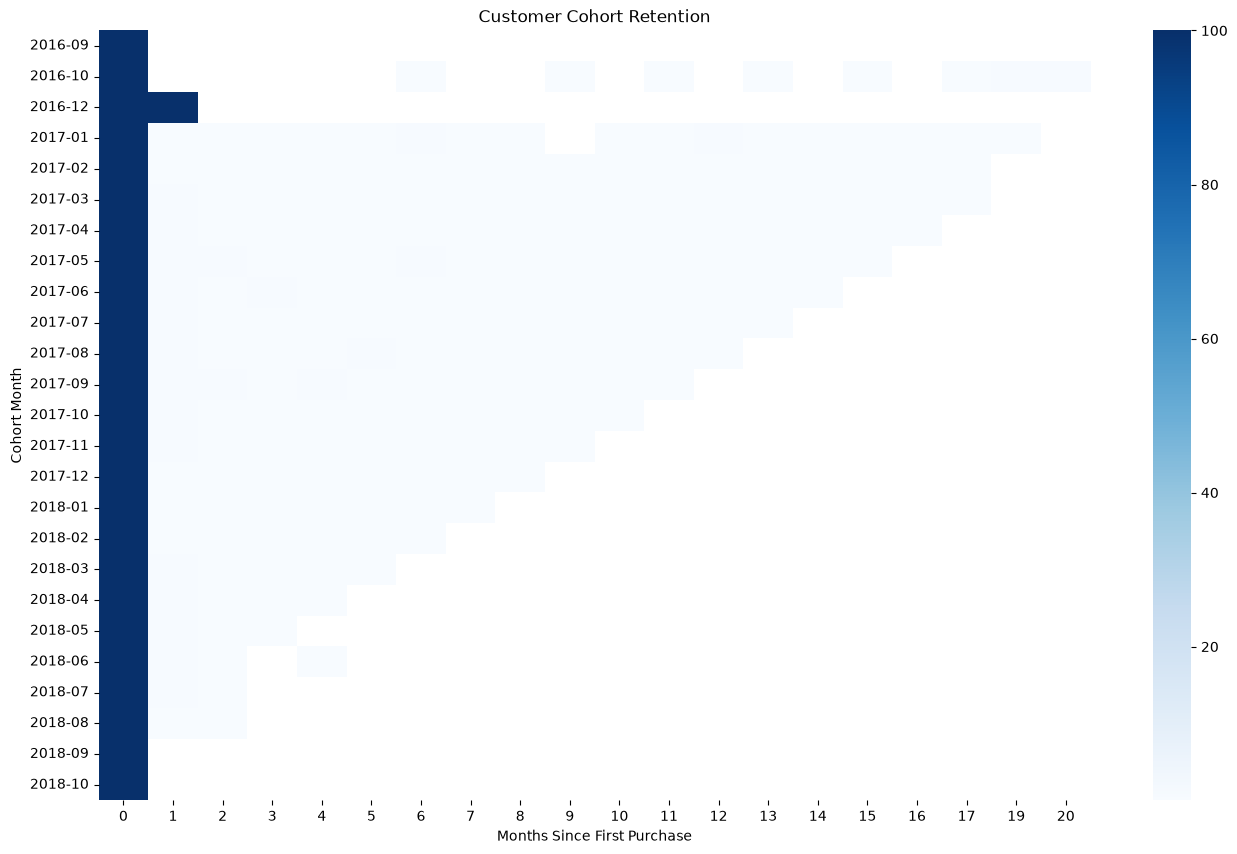

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10))

sns.heatmap(
    retention_matrix,
    annot=False,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Customer Cohort Retention")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()

## Customer Analysis — Business Insights

### Key Findings

1. **Customer acquisition increased significantly over time**
   - The number of unique customers grew substantially during 2017 and 2018.
   - This indicates strong growth in the customer base.

2. **The customer base is heavily driven by new customers**
   - New customers represent the majority of monthly unique customers.
   - Repeat customers form a relatively small proportion of monthly customers.

3. **Repeat-customer participation improved over time**
   - The repeat-customer rate generally increased during the mature period of the dataset.
   - It reached approximately 3% around June 2018.

4. **Customer retention declines after the first purchase**
   - Cohort analysis shows that retention is highest in Month 0 and generally decreases as the number of months since the first purchase increases.
   - This suggests that maintaining long-term customer engagement is a challenge.

5. **Recent months require caution**
   - September and October 2018 contain very few orders compared with previous months.
   - Their unusually high repeat-customer percentages are therefore not representative of normal customer behavior.

### Business Recommendations

- Develop strategies to encourage second purchases.
- Use targeted promotions for customers shortly after their first purchase.
- Identify products associated with higher repeat-purchase behavior.
- Monitor cohort retention regularly to evaluate customer loyalty.
- Investigate why customer retention remains relatively low despite growth in customer acquisition.